# Create LLM Evaluation Figure

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hiatus.config import metrics, metrics_dir, plots_dir

In [5]:
baseline_metrics_dir = "/gscratch/ifml1/hiatus/metrics/"
plots_dir.mkdir(parents=True, exist_ok=True)

In [6]:
mpl.rcParams.update({
	"lines.linewidth": 2.0,
	"xtick.labelsize": 20,
	"ytick.labelsize": 20,
	"axes.labelsize": 20,
	"legend.fontsize": 20,
	"axes.titlesize": 20,
	"font.family": "sans-serif",
	"pdf.fonttype": 42,
	"ps.fonttype": 42,
	"figure.labelsize": 20,
	"text.usetex": False,
})

In [7]:
def load_results(paths, sense_scores=True) -> pd.DataFrame:
	results = pd.DataFrame()
	for path in paths:
		if sense_scores:
			data = pd.read_json(path, lines=True)
		else:
			data = pd.read_csv(path)

		results = pd.concat([results, data])
	return results

In [ ]:
use_old_ar_model = True
ar_sense_code = "ar_old_model" if use_old_ar_model else "ar"

metrics_path = {
    # Baselines, reported in Dec
	"prompt-remix-zh0-1": {
		"language": "zh",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*1_ta3_results.csv")],
		"color": ("#027100", 0.2),
		"label": "PromptRemix-ZH0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-zh0-2": {
		"language": "zh",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*2_ta3_results.csv")],
		"color": ("#027100", 0.5),
		"label": "PromptRemix-ZH0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-zh0-3": {
		"language": "zh",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*3_ta3_results.csv")],
		"color": ("#027100", 0.8),
		"label": "PromptRemix-ZH0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar0-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "PromptRemix-AR0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar0-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "PromptRemix-AR0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar0-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "PromptRemix-AR0-3",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar20-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "PromptRemix-AR20",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar20-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "PromptRemix-AR20",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar20-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "PromptRemix-AR0-3",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-enF-1": {
		"language": "en",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*1_ta3_results.csv")],
		"color": ("#004D80", 0.2),
		"label": "PromptRemix-ENF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-enF-2": {
		"language": "en",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*2_ta3_results.csv")],
		"color": ("#004D80", 0.5),
		"label": "PromptRemix-ENF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-enF-3": {
		"language": "en",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*3_ta3_results.csv")],
		"color": ("#004D80", 0.8),
		"label": "PromptRemix-ENF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-ruF-1": {
		"language": "ru",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*1_ta3_results.csv")],
		"color": ("#800000", 0.2),
		"label": "PromptRemix-RUF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-ruF-2": {
		"language": "ru",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*2_ta3_results.csv")],
		"color": ("#800000", 0.5),
		"label": "PromptRemix-RUF-2",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-ruF-3": {
		"language": "ru",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*3_ta3_results.csv")],
		"color": ("#800000", 0.8),
		"label": "PromptRemix-RUF",
        "hatch": False,
		"report": True,
	},

	# AR Baseline
    "prompt-remix-ar20-baseline-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-baseline-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-baseline-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "PromptRemix-AR20-Baseline",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar20-baseline-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-baseline-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-baseline-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "PromptRemix-AR20-Baseline",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar20-baseline-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-baseline-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-baseline-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "PromptRemix-AR0-3-Baseline",
		"hatch": False,
		"report": True,
	},

	# # # Qwen 3.5 metrics
    "prompt-remix-zh0-qwen3.5-1": {
		"language": "zh",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-1_ta3_results.csv")],
		"color": ("#027100", 0.2),
		"label": "PromptRemix-ZH0-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-qwen3.5-2": {
		"language": "zh",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-2_ta3_results.csv")],
		"color": ("#027100", 0.5),
		"label": "PromptRemix-ZH0-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-qwen3.5-3": {
		"language": "zh",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-3_ta3_results.csv")],
		"color": ("#027100", 0.8),
		"label": "PromptRemix-ZH0-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "PromptRemix-AR22-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "PromptRemix-AR22-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "PromptRemix-AR22-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-1": {
		"language": "en",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-1_ta3_results.csv")],
		"color": ("#004D80", 0.2),
		"label": "PromptRemix-ENF-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-2": {
		"language": "en",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-2_ta3_results.csv")],
		"color": ("#004D80", 0.5),
		"label": "PromptRemix-ENF-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-3": {
		"language": "en",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-3_ta3_results.csv")],
		"color": ("#004D80", 0.8),
		"label": "PromptRemix-ENF-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-1": {
		"language": "ru",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-1_ta3_results.csv")],
		"color": ("#800000", 0.2),
		"label": "PromptRemix-RU-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-2": {
		"language": "ru",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-2_ta3_results.csv")],
		"color": ("#800000", 0.5),
		"label": "PromptRemix-RU-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-3": {
		"language": "ru",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-3_ta3_results.csv")],
		"color": ("#800000", 0.8),
		"label": "PromptRemix-RU-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    
	# # Style transfer metrics
    "prompt-remix-zh0-transfer-qwen3_5-1": {
		"language": "zh",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-1_ta3_results.csv")],
		"color": ("#027100", 0.2),
		"label": "PromptRemix-ZH0-Transfer-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-transfer-qwen3_5-2": {
		"language": "zh",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-2_ta3_results.csv")],
		"color": ("#027100", 0.5),
		"label": "PromptRemix-ZH0-Transfer-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-transfer-qwen3_5-3": {
		"language": "zh",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-3_ta3_results.csv")],
		"color": ("#027100", 0.8),
		"label": "PromptRemix-ZH0-Transfer-Qwen3.5",
		"hatch": False,
		"report": True,
	},
    
	# Constrained Decoding Metrics
    "prompt-remix-zh0-qwen3.5-constr-1": {
		"language": "zh",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-1_ta3_results.csv")],
		"color": ("#027100", 0.2),
		"label": "PromptRemix-ZH0-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-qwen3.5-constr-2": {
		"language": "zh",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-2_ta3_results.csv")],
		"color": ("#027100", 0.5),
		"label": "PromptRemix-ZH0-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-qwen3.5-constr-3": {
		"language": "zh",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-3_ta3_results.csv")],
		"color": ("#027100", 0.8),
		"label": "PromptRemix-ZH0-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-constr-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-constr-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-constr-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "PromptRemix-AR22-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-constr-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-constr-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-constr-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "PromptRemix-AR22-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-constr-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-constr-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-constr-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "PromptRemix-AR22-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-constr-1": {
		"language": "en",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-1_ta3_results.csv")],
		"color": ("#004D80", 0.2),
		"label": "PromptRemix-ENF-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-constr-2": {
		"language": "en",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-2_ta3_results.csv")],
		"color": ("#004D80", 0.5),
		"label": "PromptRemix-ENF-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-constr-3": {
		"language": "en",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-3_ta3_results.csv")],
		"color": ("#004D80", 0.8),
		"label": "PromptRemix-ENF-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-constr-1": {
		"language": "ru",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-1_ta3_results.csv")],
		"color": ("#800000", 0.2),
		"label": "PromptRemix-RU-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-constr-2": {
		"language": "ru",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-2_ta3_results.csv")],
		"color": ("#800000", 0.5),
		"label": "PromptRemix-RU-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-constr-3": {
		"language": "ru",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-3_ta3_results.csv")],
		"color": ("#800000", 0.8),
		"label": "PromptRemix-RU-Qwen3.5-Constrained",
		"hatch": False,
		"report": True,
	},
}

## Sense Scores

In [14]:
def get_genre(path):
    stem = Path(path).stem
    genre = stem.split("_promptremix")[0]
    return genre


In [15]:
columns = list(metrics.keys())[:6]

df_list = []

for model_name, cfg in metrics_path.items():
    if not cfg["report"]:
        continue

    for file_path in cfg["sense_scores"]:
        results = load_results([file_path])
        results.drop(columns="documentID", errors="ignore", inplace=True)
        results = results[columns]

        # Apply scaling
        for col in results.columns:
            if col in metrics:
                results[col] = results[col] * metrics[col]["scale"]

        # Assign genre and metadata
        genre = get_genre(file_path)
        results['genre'] = genre
        results['n_styles_to_change'] = cfg['n_styles_to_change']
        results['model_label'] = cfg['label']
        results['language'] = cfg['language']

        df_list.append(results)

# Concatenate all rows
df = pd.concat(df_list, ignore_index=True)

# Compute mean per genre
df = df.groupby(['language', 'genre', 'n_styles_to_change', 'model_label']).mean().reset_index()


In [16]:
# For English, remove HRS2 genres
df_plot = df.copy()
if 'en' in df_plot['language'].unique():
    df_plot = df_plot[~((df_plot['language'] == 'en') & (df_plot['genre'].str.contains('HRS2')))]


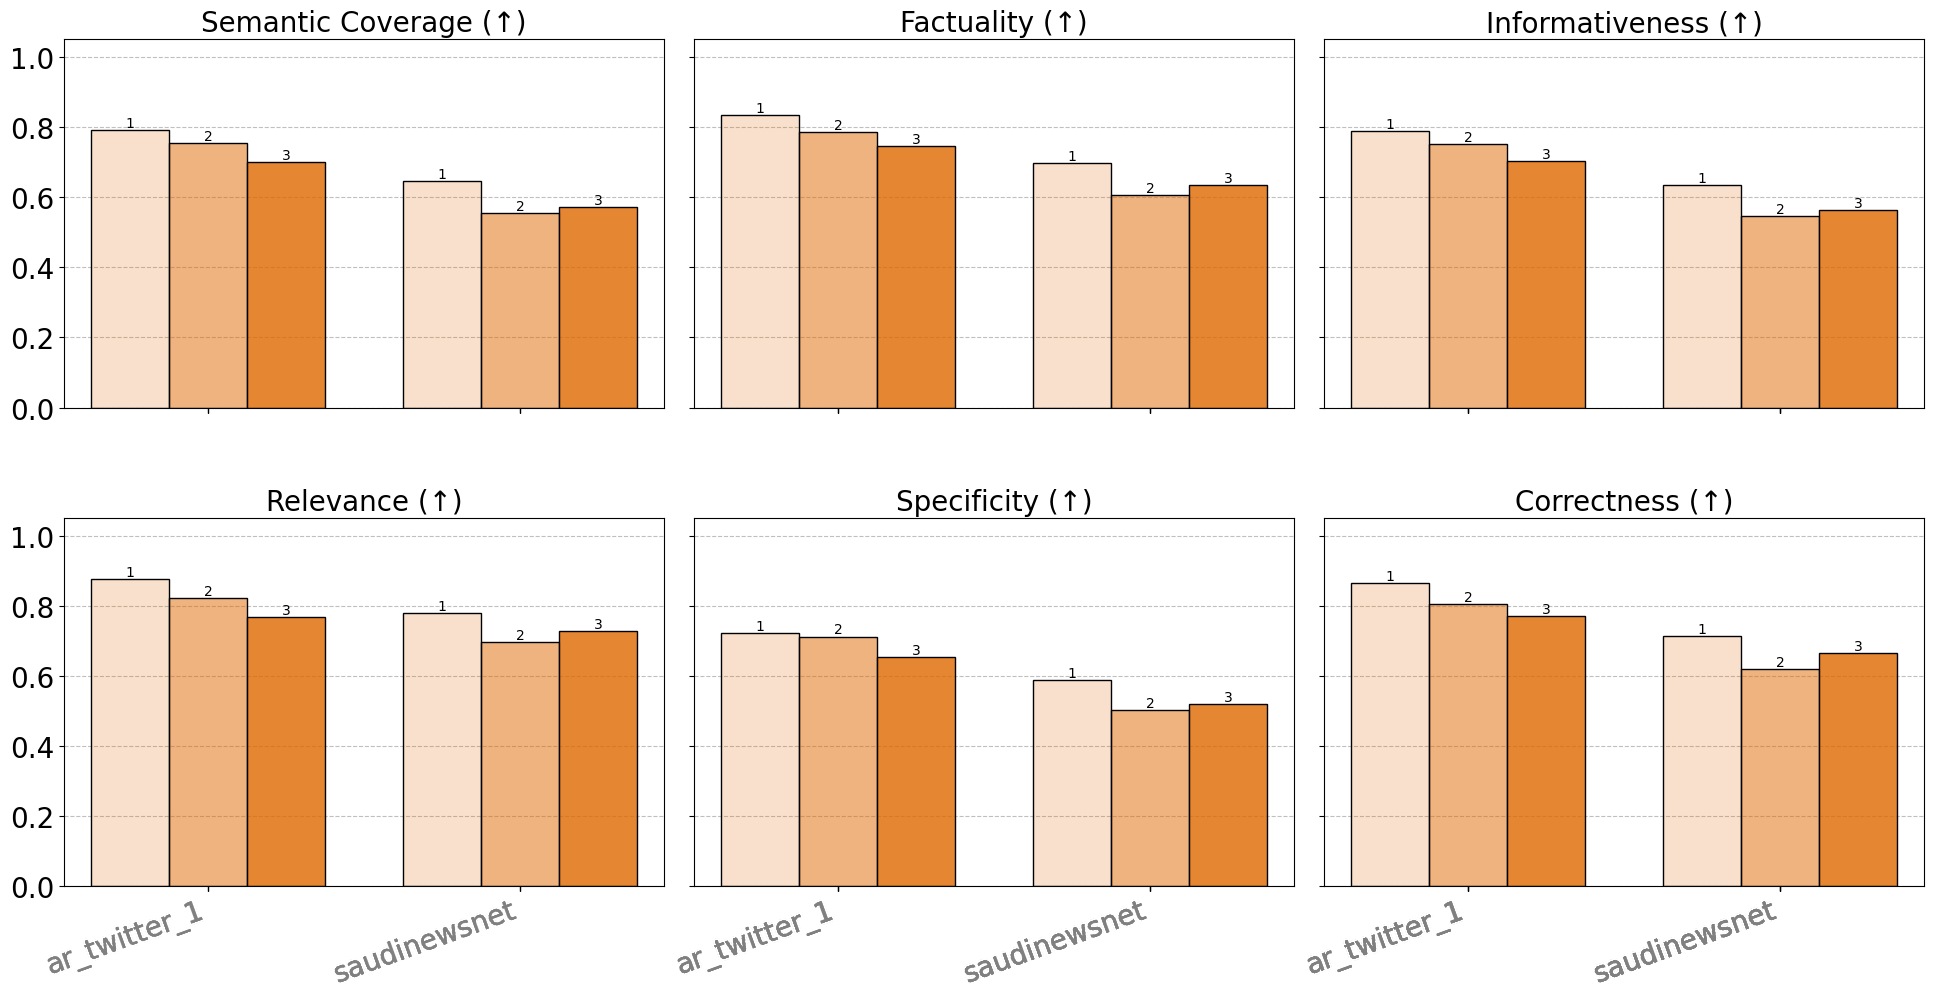

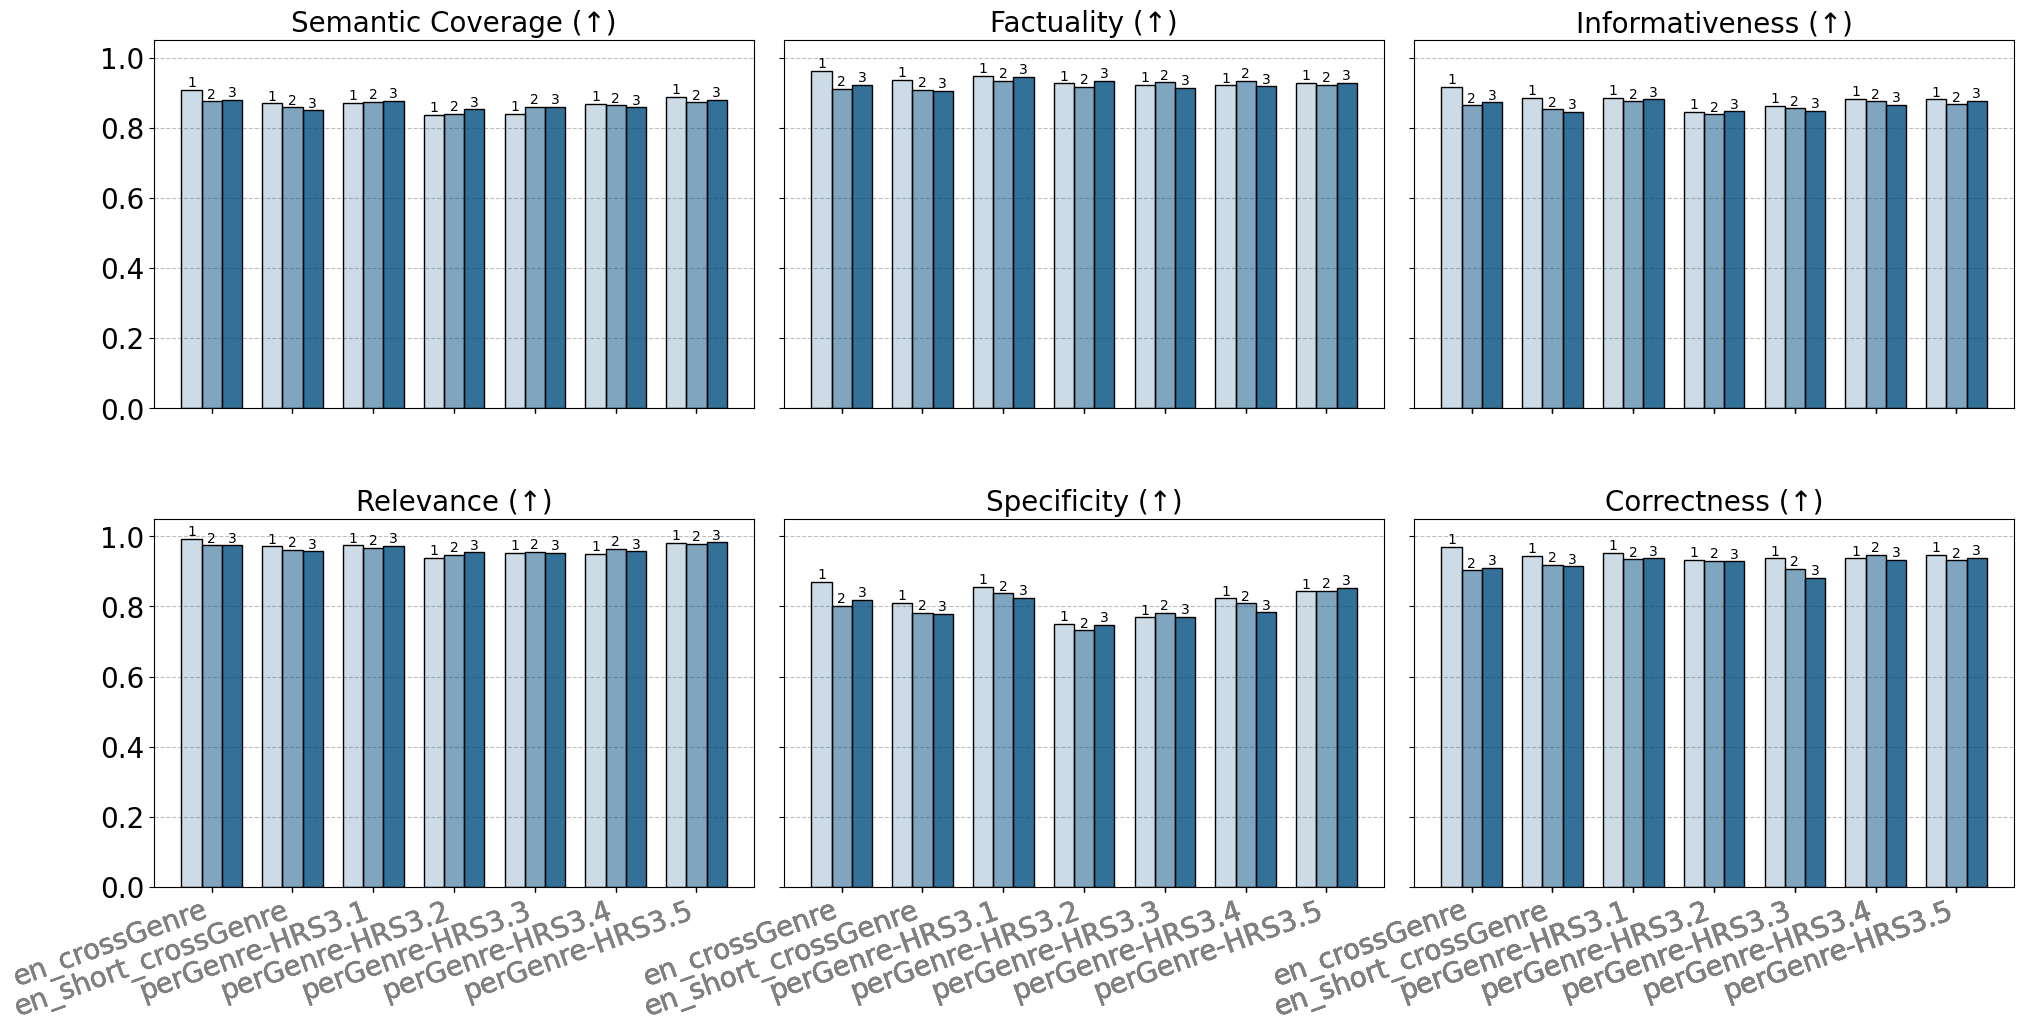

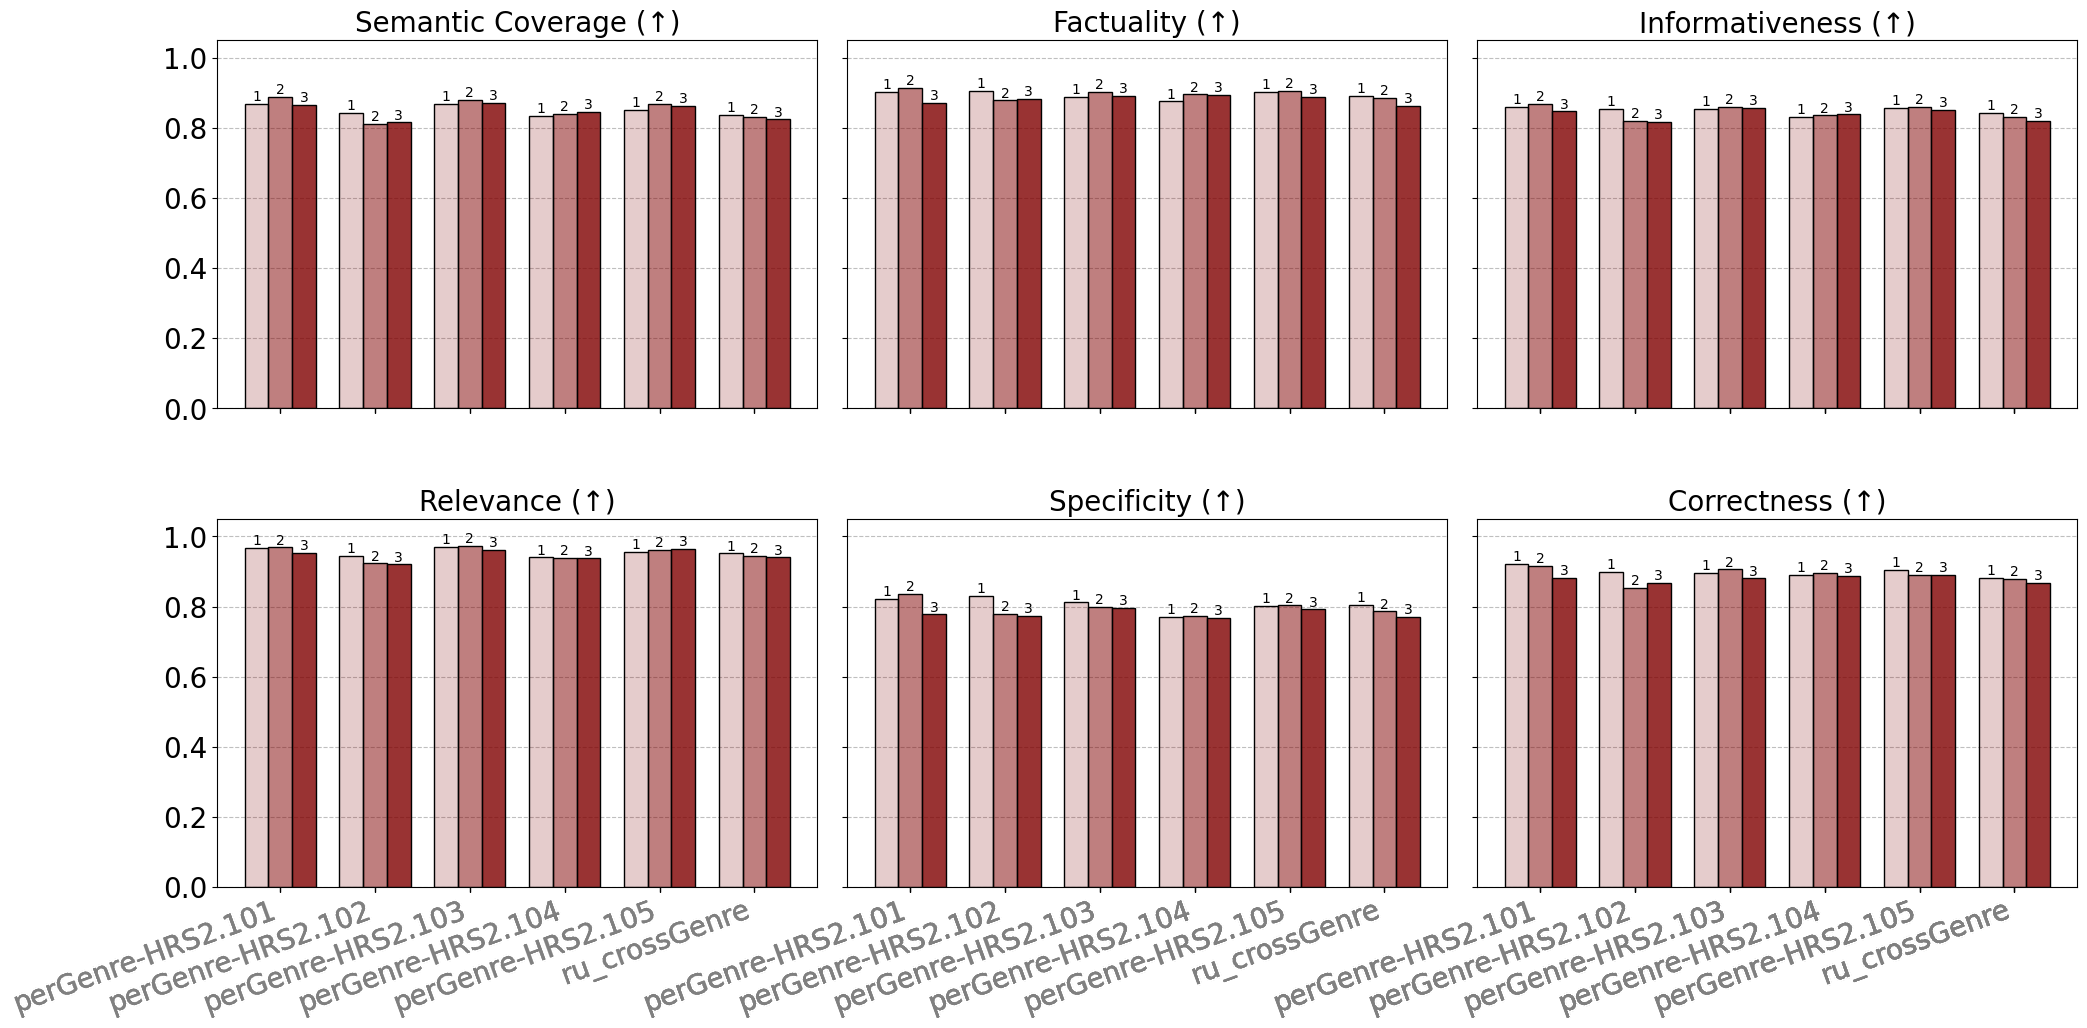

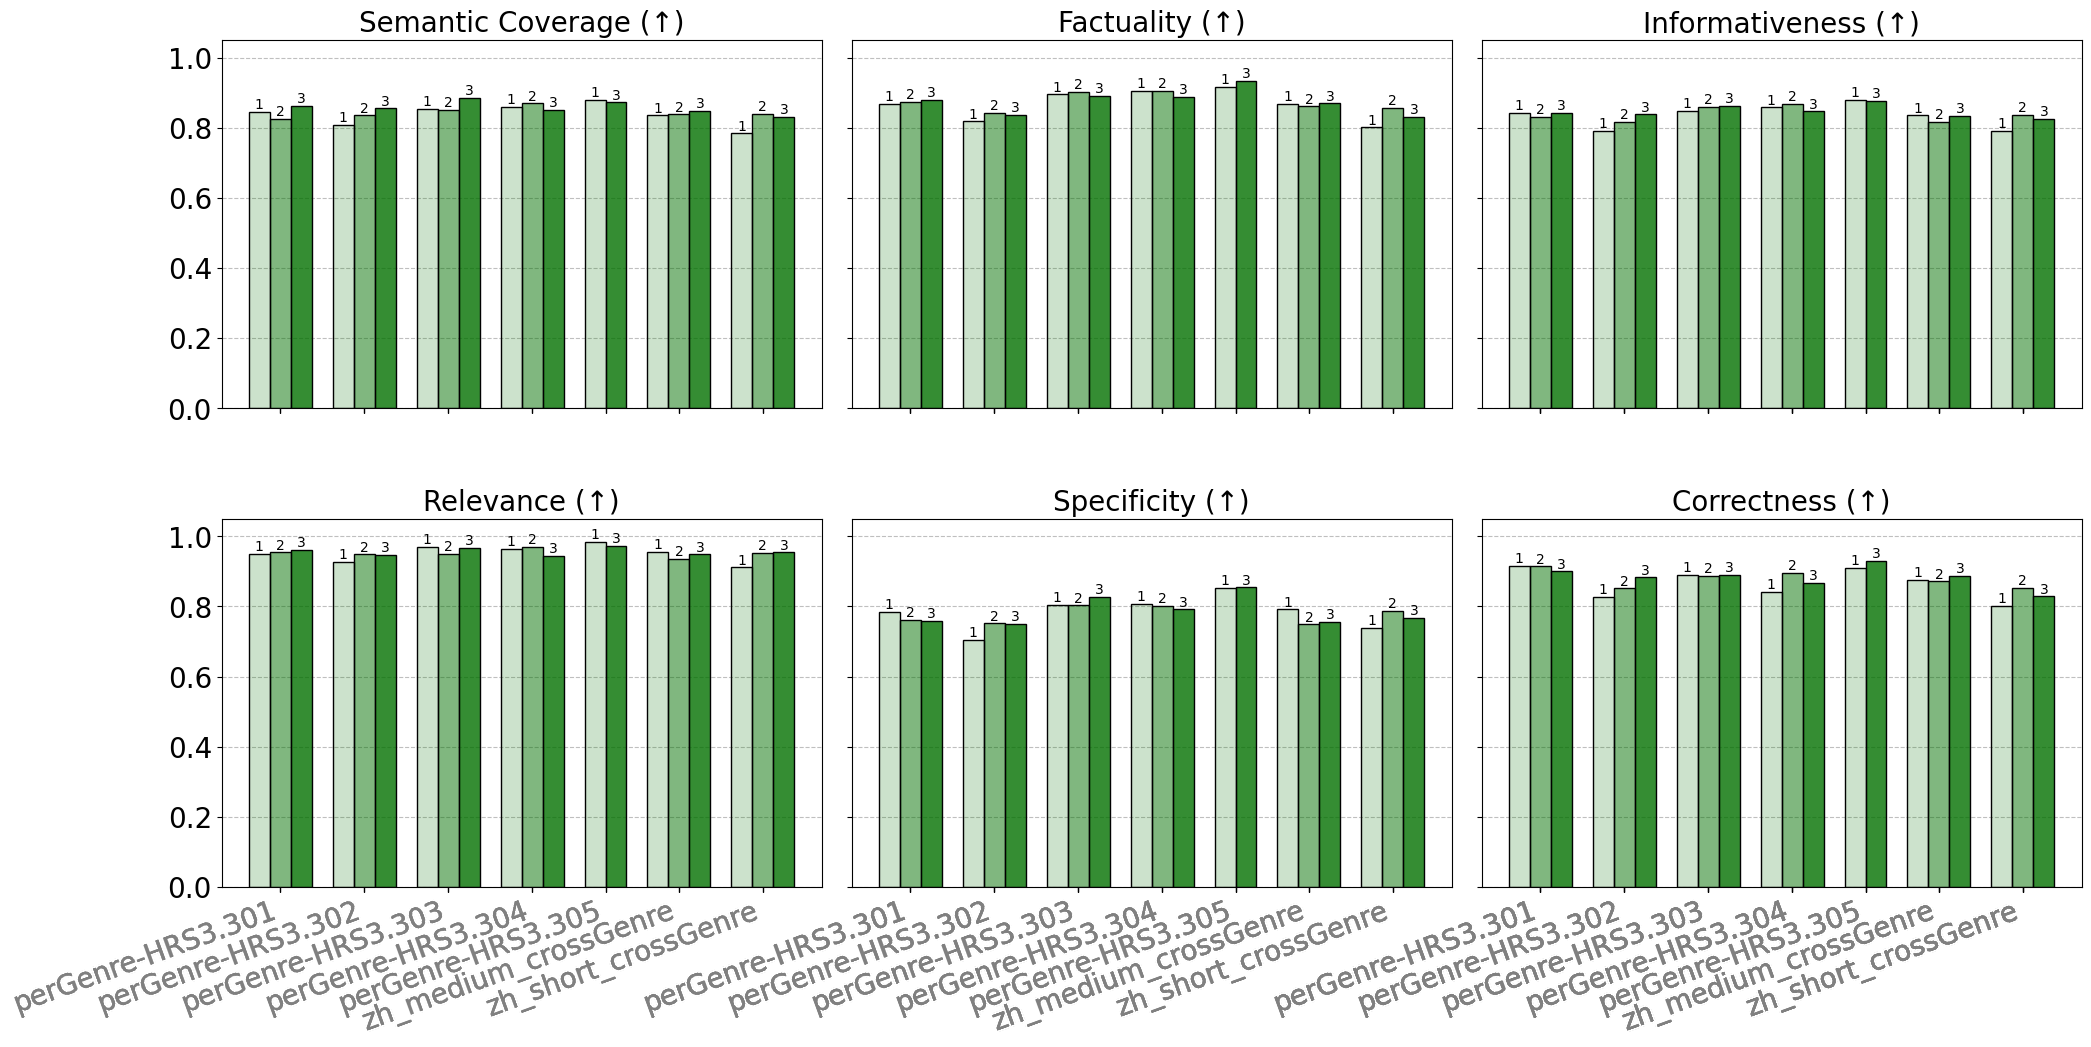

In [17]:
metric_cols = columns[:6]  # metrics to plot
width = 0.2  # width of each bar within a genre
gap = 0.4    # space between genres

# Filter English HRS2 genres
df_plot = df.copy()
if 'en' in df_plot['language'].unique():
    df_plot = df_plot[~((df_plot['language'] == 'en') & (df_plot['genre'].str.contains('HRS2')))]

# Prettify metric titles
def prettify_title(col):
    return metrics[col]["title"] if col in metrics else col

# Plot each language separately
for lang in df_plot['language'].unique():
    df_lang = df_plot[df_plot['language'] == lang].sort_values(['genre', 'n_styles_to_change'])
    genres = df_lang['genre'].unique()
    
    x_ticks = []
    x_ticklabels = []

    fig, axes = plt.subplots(2, 3, figsize=(24, 11), sharey='row', sharex='col')

    for i, ax in enumerate(axes.flatten()):
        if i >= len(metric_cols):
            ax.axis('off')
            continue

        metric = metric_cols[i]
        cursor = 0

        for genre in genres:
            df_genre = df_lang[df_lang['genre'] == genre].sort_values('n_styles_to_change')
            x = cursor + np.arange(len(df_genre)) * width

            # Map colors and hatches
            repeated_colors = []
            repeated_hatches = []
            for style in df_genre['n_styles_to_change']:
                for m in metrics_path:
                    if (metrics_path[m]['report']
                        and metrics_path[m]['language'] == lang
                        and metrics_path[m]['n_styles_to_change'] == style):
                        repeated_colors.append(metrics_path[m]['color'])
                        repeated_hatches.append('/' if metrics_path[m]['hatch'] else '')

            rect = ax.bar(
                x,
                df_genre[metric],
                width=width,
                color=repeated_colors,
                hatch=repeated_hatches,
                edgecolor='black',
                linewidth=1.0,
                zorder=1
            )

            # Bar labels = n_styles_to_change
            style_labels = df_genre['n_styles_to_change'].astype(str).tolist()
            ax.bar_label(rect, style_labels, padding=0)

            cursor = x[-1] + gap
            x_ticks.append(x.mean())
            x_ticklabels.append(genre)

        # Prettified title per metric
        ax.set_title(prettify_title(metric))
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticklabels, rotation=20, ha='right', color='grey')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', which='major', color='gray', alpha=0.5, linestyle='dashed')
        ax.set_axisbelow(True)
 
    plt.subplots_adjust(wspace=0.05, hspace=0.3)

    path = Path(plots_dir, f"prompt-remix-{lang}-per-genre1.pdf")
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path.as_posix(), bbox_inches="tight")
    plt.show()


In [10]:
columns = list(metrics.keys())[6:12]

df_list = []

for model_name, cfg in metrics_path.items():
    if not cfg["report"]:
        continue

    for file_path in cfg["sense_scores"]:
        results = load_results([file_path])
        results.drop(columns="documentID", errors="ignore", inplace=True)
        results = results[columns]

        # Apply scaling
        for col in results.columns:
            if col in metrics:
                results[col] = results[col] * metrics[col]["scale"]

        # Assign genre and metadata
        genre = get_genre(file_path)
        results['genre'] = genre
        results['n_styles_to_change'] = cfg['n_styles_to_change']
        results['model_label'] = cfg['label']
        results['language'] = cfg['language']

        df_list.append(results)

# Concatenate all rows
df = pd.concat(df_list, ignore_index=True)

# Compute mean per genre
df = df.groupby(['language', 'genre', 'n_styles_to_change', 'model_label']).mean().reset_index()


In [11]:
# For English, remove HRS2 genres
df_plot = df.copy()
if 'en' in df_plot['language'].unique():
    df_plot = df_plot[~((df_plot['language'] == 'en') & (df_plot['genre'].str.contains('HRS2')))]


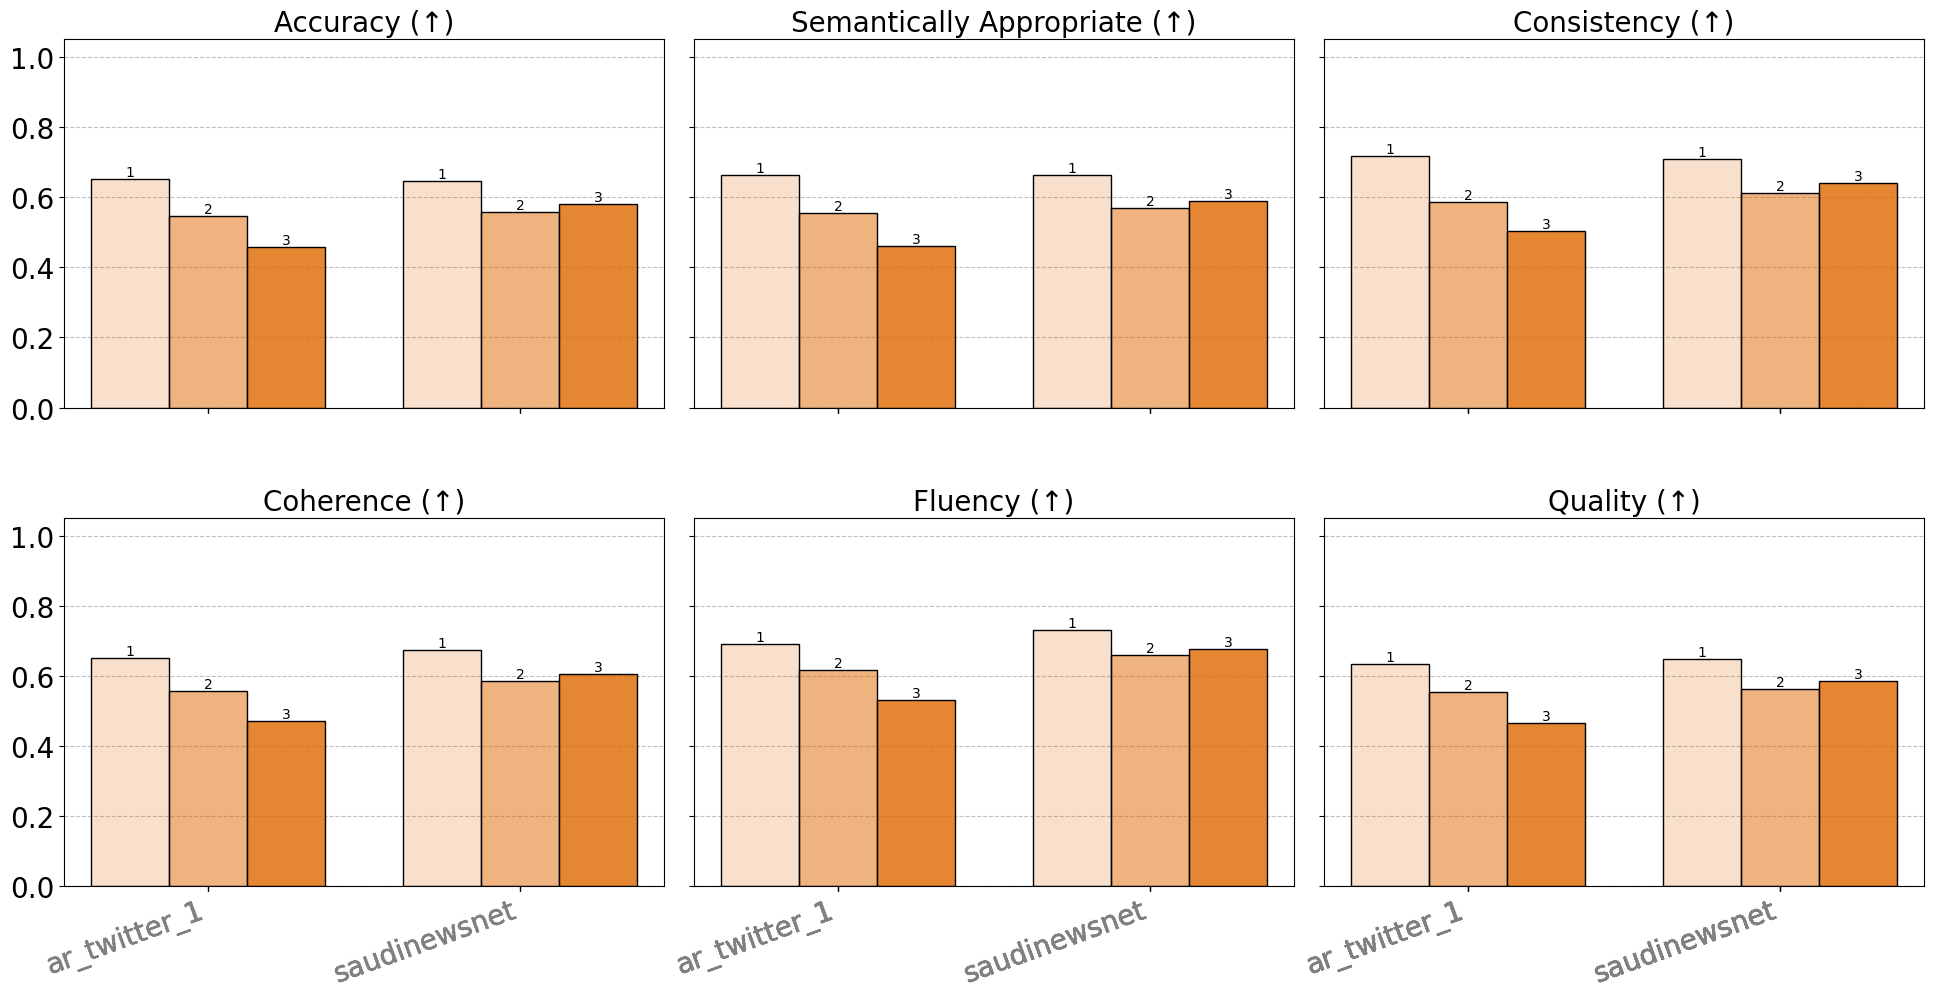

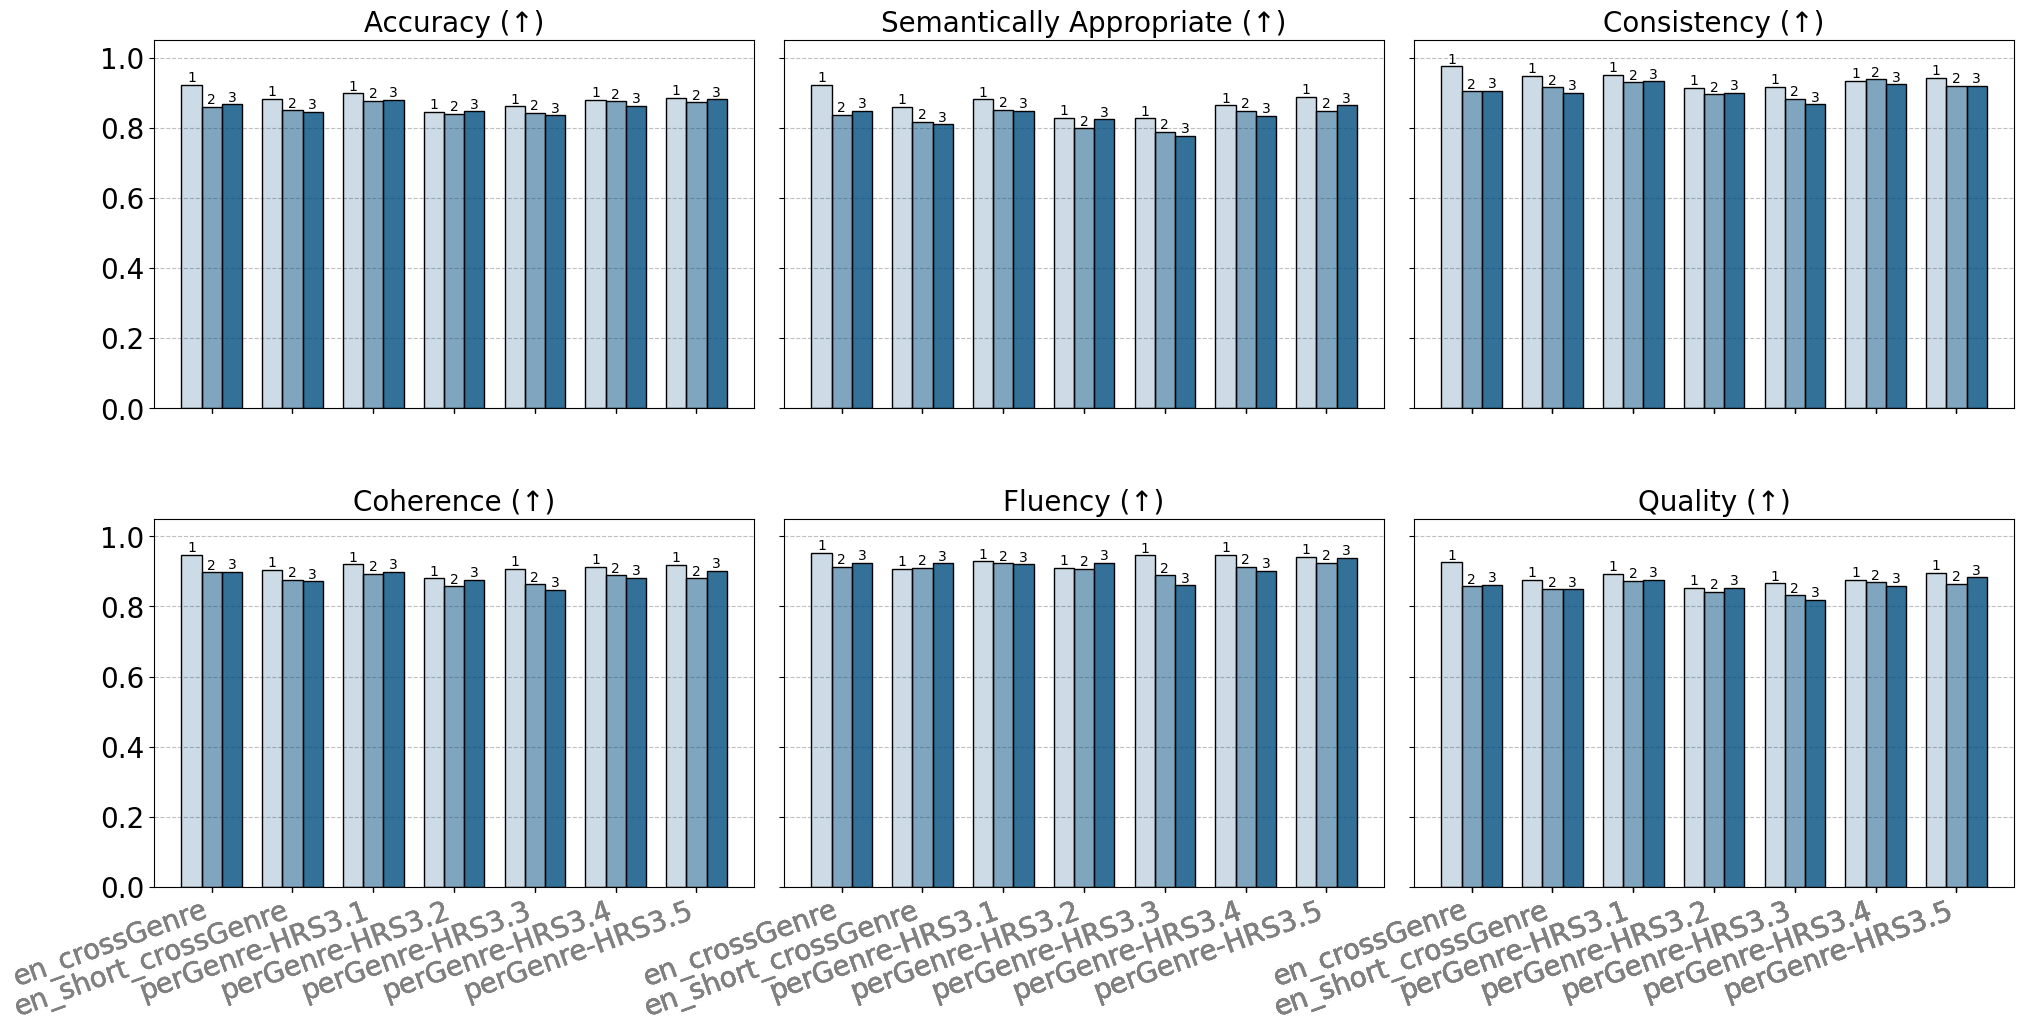

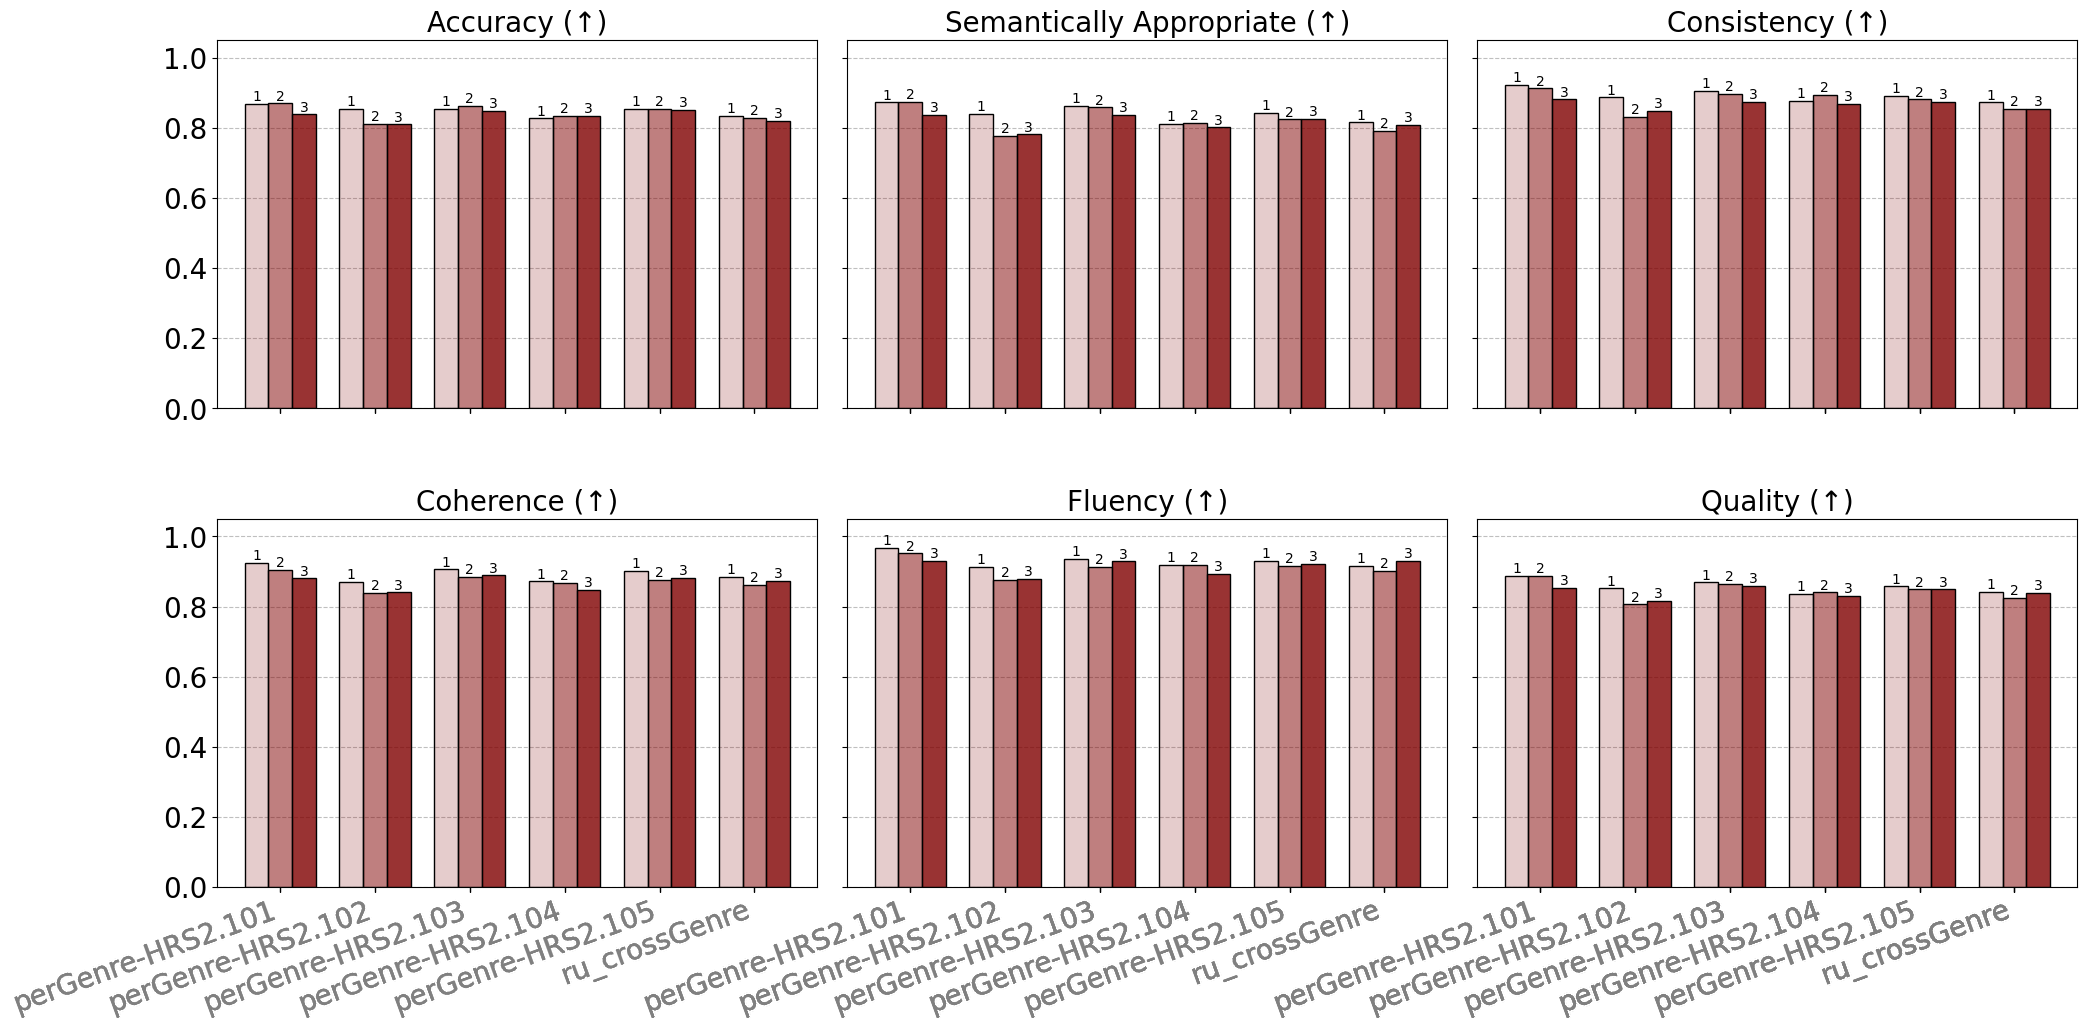

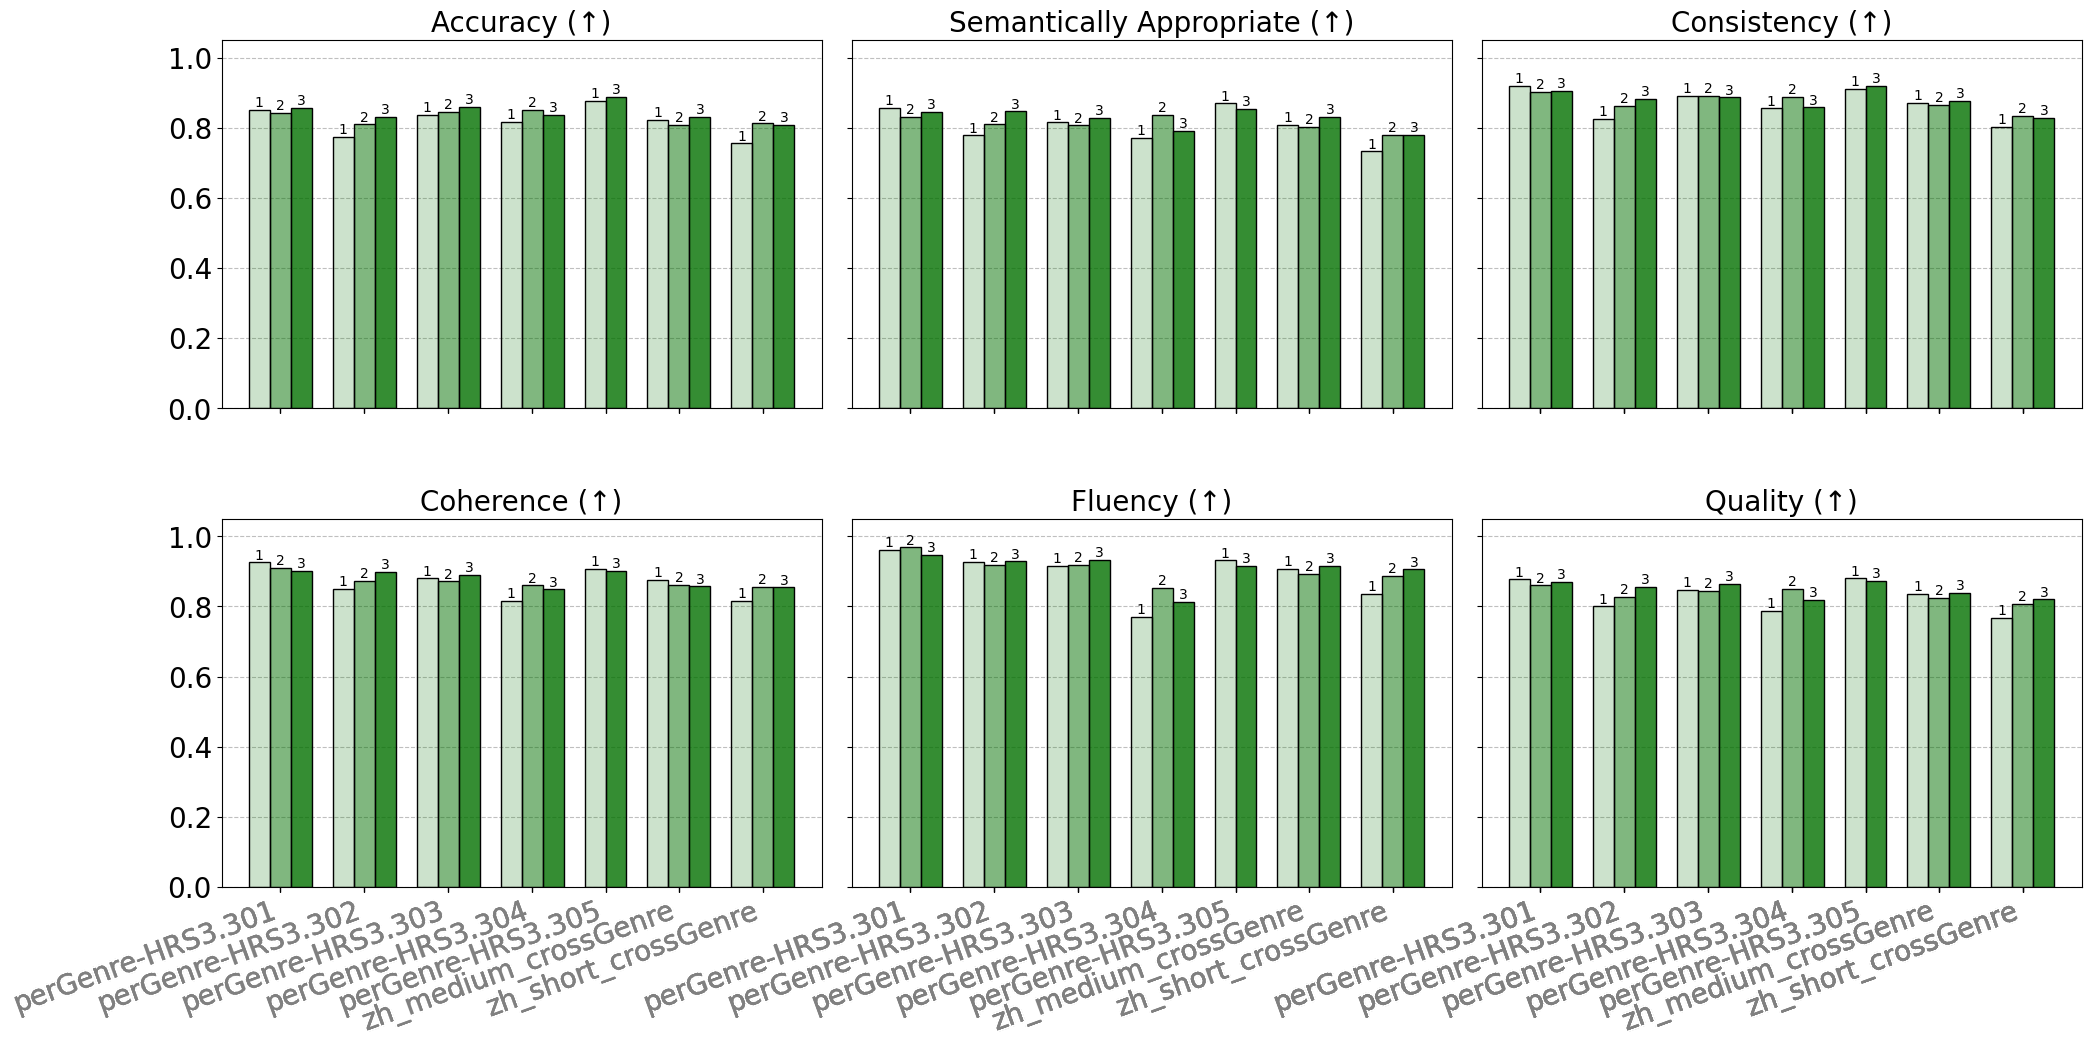

In [12]:
metric_cols = columns[:6]  # metrics to plot
width = 0.2  # width of each bar within a genre
gap = 0.4    # space between genres

# Filter English HRS2 genres
df_plot = df.copy()
if 'en' in df_plot['language'].unique():
    df_plot = df_plot[~((df_plot['language'] == 'en') & (df_plot['genre'].str.contains('HRS2')))]

# Prettify metric titles
def prettify_title(col):
    return metrics[col]["title"] if col in metrics else col

# Plot each language separately
for lang in df_plot['language'].unique():
    df_lang = df_plot[df_plot['language'] == lang].sort_values(['genre', 'n_styles_to_change'])
    genres = df_lang['genre'].unique()
    
    x_ticks = []
    x_ticklabels = []

    fig, axes = plt.subplots(2, 3, figsize=(24, 11), sharey='row', sharex='col')

    for i, ax in enumerate(axes.flatten()):
        if i >= len(metric_cols):
            ax.axis('off')
            continue

        metric = metric_cols[i]
        cursor = 0

        for genre in genres:
            df_genre = df_lang[df_lang['genre'] == genre].sort_values('n_styles_to_change')
            x = cursor + np.arange(len(df_genre)) * width

            # Map colors and hatches
            repeated_colors = []
            repeated_hatches = []
            for style in df_genre['n_styles_to_change']:
                for m in metrics_path:
                    if (metrics_path[m]['report']
                        and metrics_path[m]['language'] == lang
                        and metrics_path[m]['n_styles_to_change'] == style):
                        repeated_colors.append(metrics_path[m]['color'])
                        repeated_hatches.append('/' if metrics_path[m]['hatch'] else '')

            rect = ax.bar(
                x,
                df_genre[metric],
                width=width,
                color=repeated_colors,
                hatch=repeated_hatches,
                edgecolor='black',
                linewidth=1.0,
                zorder=1
            )

            # Bar labels = n_styles_to_change
            style_labels = df_genre['n_styles_to_change'].astype(str).tolist()
            ax.bar_label(rect, style_labels, padding=0)

            cursor = x[-1] + gap
            x_ticks.append(x.mean())
            x_ticklabels.append(genre)

        # Prettified title per metric
        ax.set_title(prettify_title(metric))
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticklabels, rotation=20, ha='right', color='grey')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', which='major', color='gray', alpha=0.5, linestyle='dashed')
        ax.set_axisbelow(True)
 
    plt.subplots_adjust(wspace=0.05, hspace=0.3)

    path = Path(plots_dir, f"prompt-remix-{lang}-per-genre2.pdf")
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path.as_posix(), bbox_inches="tight")
    plt.show()


## Privacy + Remaining Sense Scores

In [13]:
df2 = pd.DataFrame()
for model_name in metrics_path.keys():
	if metrics_path[model_name]["report"] == False:
		continue

	results = load_results(metrics_path[model_name]["privacy_consistency"], sense_scores=False)
	results = results.iloc[:, :1]
	print(results)
	
	results = results.mean(axis=0).to_frame(name="mean")
	results.index = [
		   metrics[key]["title"] if key in metrics else key for key in results.index
	   ]
	results = results.T

	df2 = pd.concat([df2, results])

   Delta Equal Error Rate
0                0.333333
0                0.125110
0                0.576969
0                0.112284
0                0.184009
0                0.203911
0                0.243352
   Delta Equal Error Rate
0                0.597951
0                0.272095
0                0.024938
0                0.226591
0                0.121344
0                0.184009
   Delta Equal Error Rate
0                0.212298
0                0.272095
0                0.104840
0                0.102099
0                0.498906
0                0.294640
0                0.341351
   Delta Equal Error Rate
0               -0.121753
0                0.140625
   Delta Equal Error Rate
0               -0.142857
0                0.187500
   Delta Equal Error Rate
0                0.174338
0               -0.142857
   Delta Equal Error Rate
0                0.310753
0                0.328705
0                0.382423
0                0.221086
0                0.253126
0           

In [14]:
columns_sense = list(metrics.keys())[12:14]  # sense score columns
privacy_col_name = "Delta Equal Error Rate (↑)"  # rename privacy column

df_list = []

# 1️⃣ Process sense scores per genre
for model_name, cfg in metrics_path.items():
    if not cfg["report"]:
        continue

    for file_path in cfg["sense_scores"]:
        results = load_results([file_path])
        results.drop(columns="documentID", errors="ignore", inplace=True)
        results = results[columns_sense]

        # Apply scaling
        for col in results.columns:
            if col in metrics:
                results[col] = results[col] * metrics[col]["scale"]

        # Assign genre and metadata
        genre = get_genre(file_path)
        results['genre'] = genre
        results['n_styles_to_change'] = cfg['n_styles_to_change']
        results['model_label'] = cfg['label']
        results['language'] = cfg['language']
        df_list.append(results)

# Concatenate and compute mean per genre
df_sense = pd.concat(df_list, ignore_index=True)
df_sense = df_sense.groupby(['language', 'genre', 'n_styles_to_change', 'model_label']).mean().reset_index()


# 2️⃣ Process privacy consistency per genre
df_priv_list = []

for model_name, cfg in metrics_path.items():
    if not cfg["report"]:
        continue

    for file_path in cfg["privacy_consistency"]:
        results = load_results([file_path], sense_scores=False)
        results = results.iloc[:, :1]  # only first column

        # Compute mean per file
        results_mean = results.mean(axis=0).to_frame(name=privacy_col_name).T

        # Prettify column names if needed
        results_mean.columns = [metrics[key]["title"] if key in metrics else key for key in results_mean.columns]

        # Extract genre
        genre = get_genre(file_path)

        # Add metadata
        results_mean['genre'] = genre
        results_mean['n_styles_to_change'] = cfg['n_styles_to_change']
        results_mean['model_label'] = cfg['label']
        results_mean['language'] = cfg['language']

        df_priv_list.append(results_mean)

df_priv = pd.concat(df_priv_list, ignore_index=True)

# 3️⃣ Merge sense scores and privacy consistency per genre
df_merged = df_sense.merge(
    df_priv,
    on=['language', 'genre', 'n_styles_to_change', 'model_label'],
    how='left'
)


In [15]:
df_merged.rename(columns={"Delta Equal Error Rate": "delta_equal_error_rate"}, inplace=True)

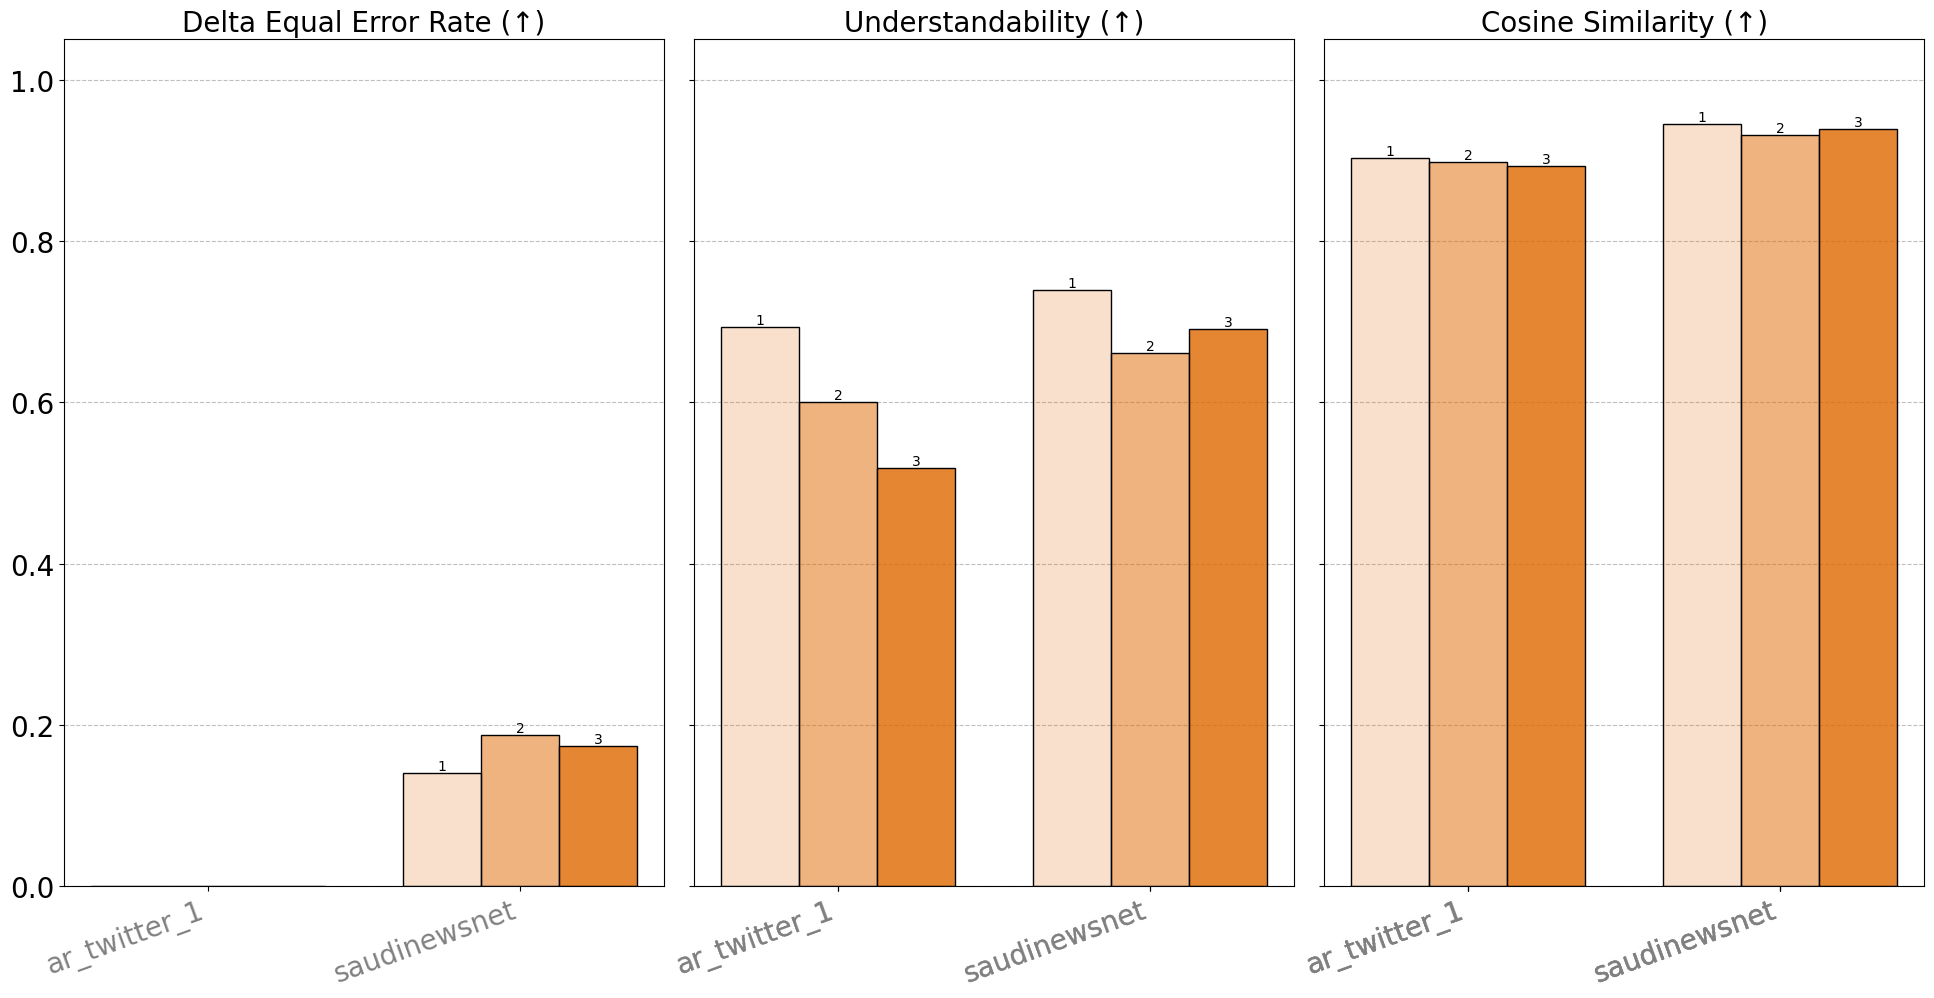

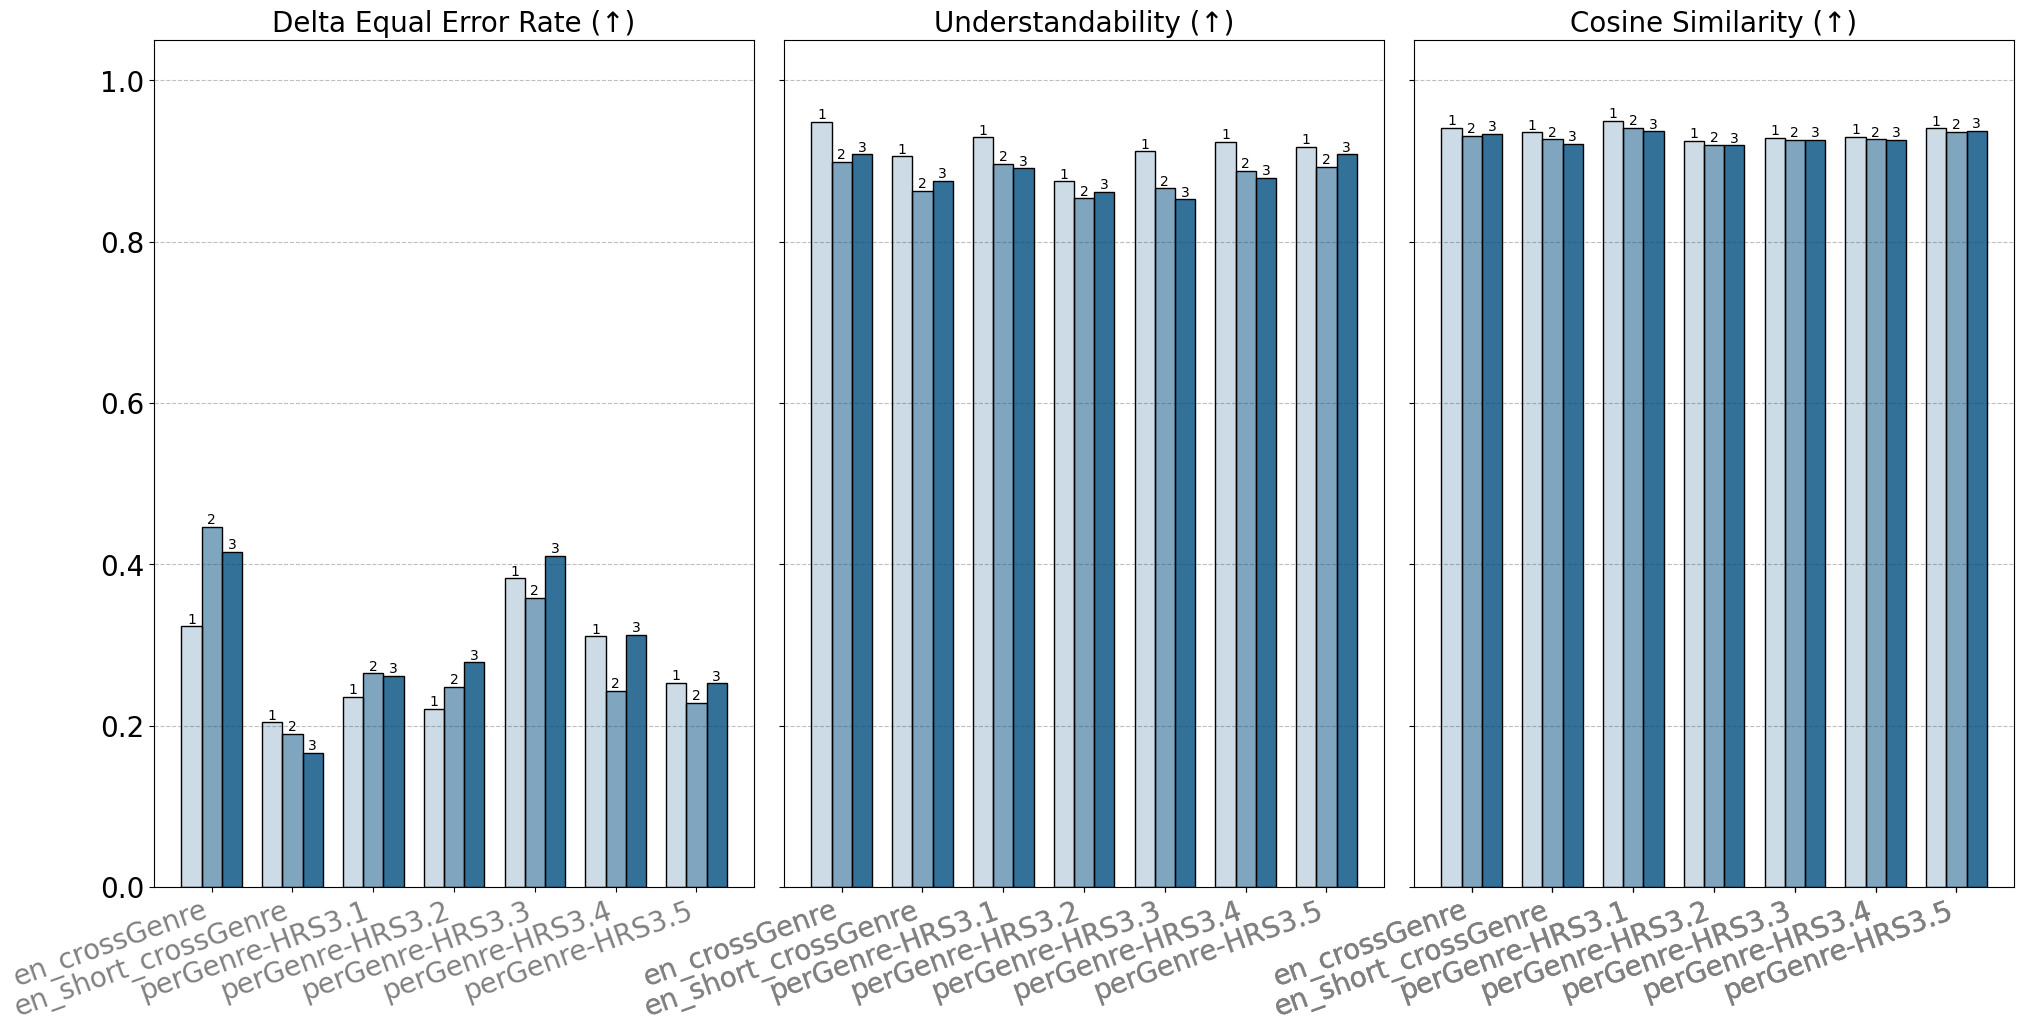

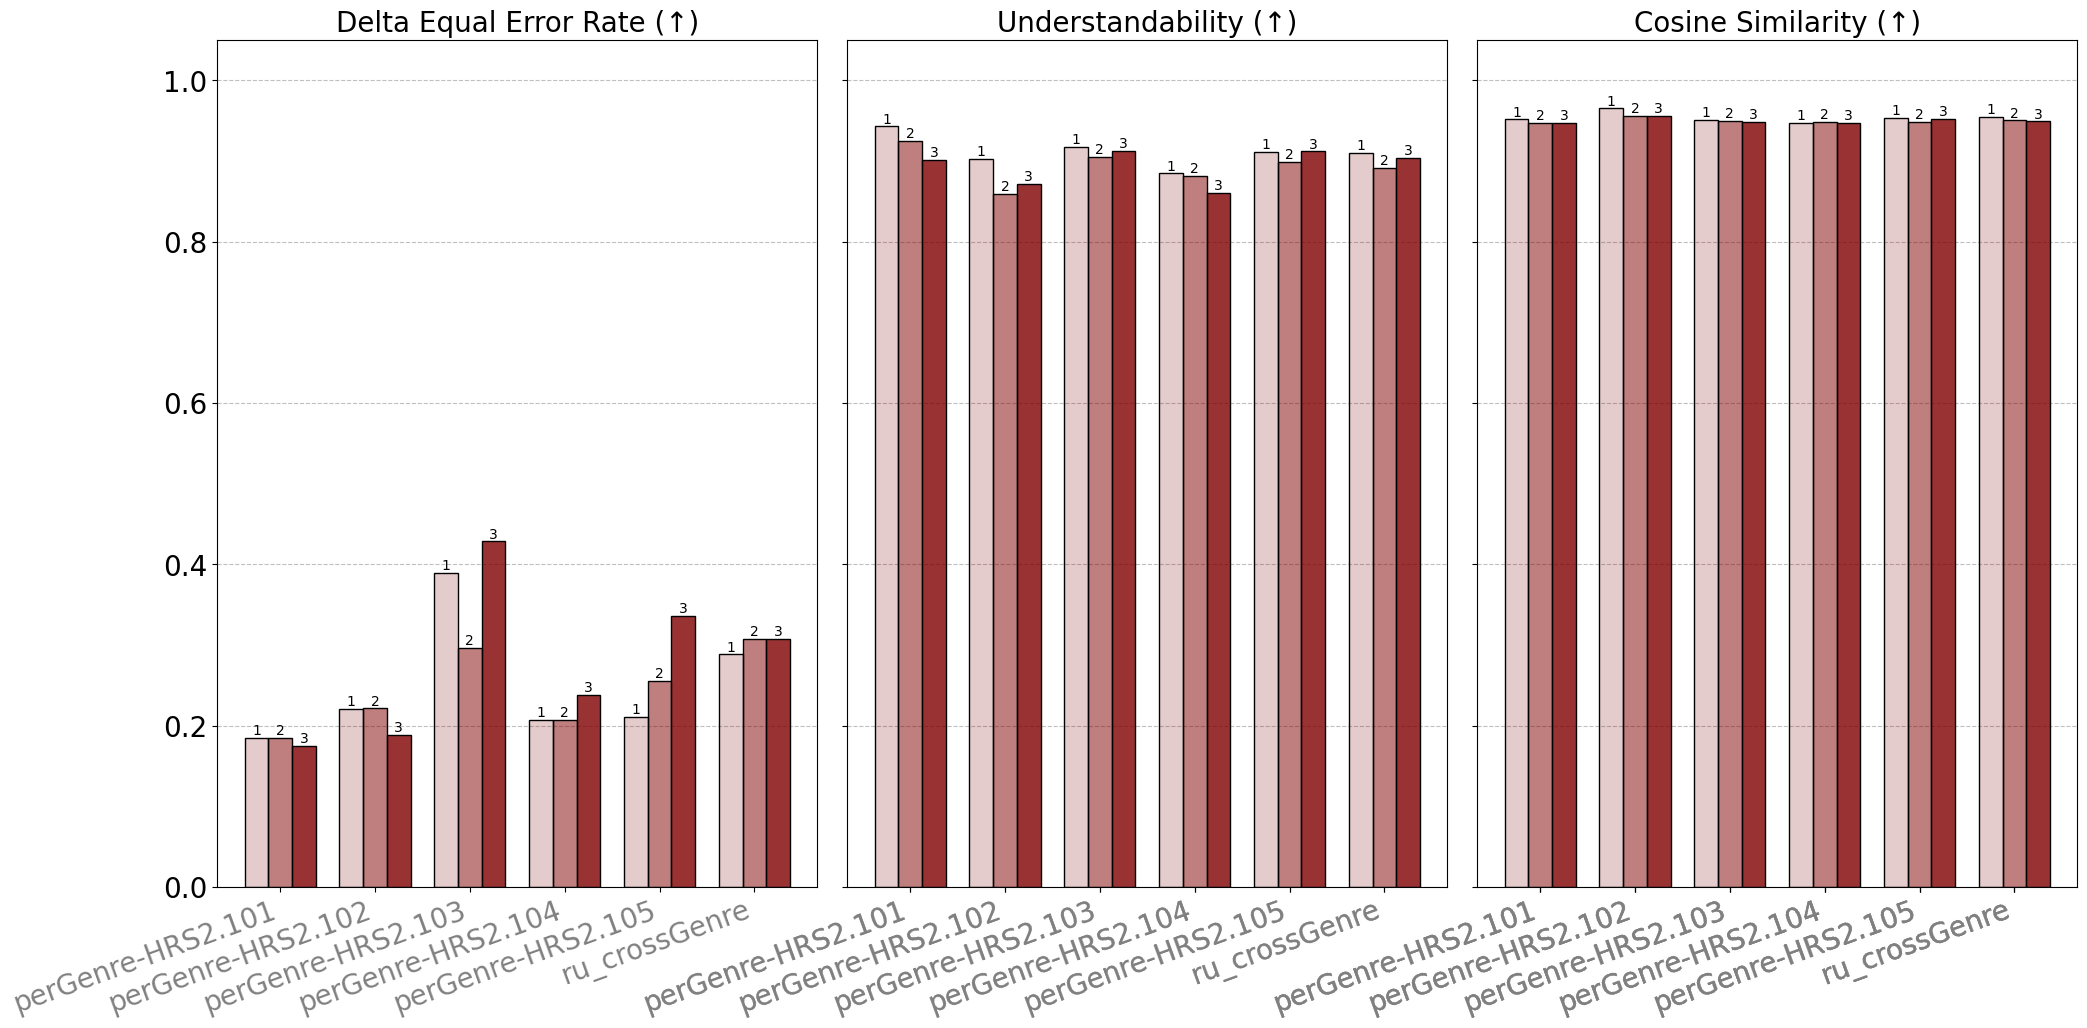

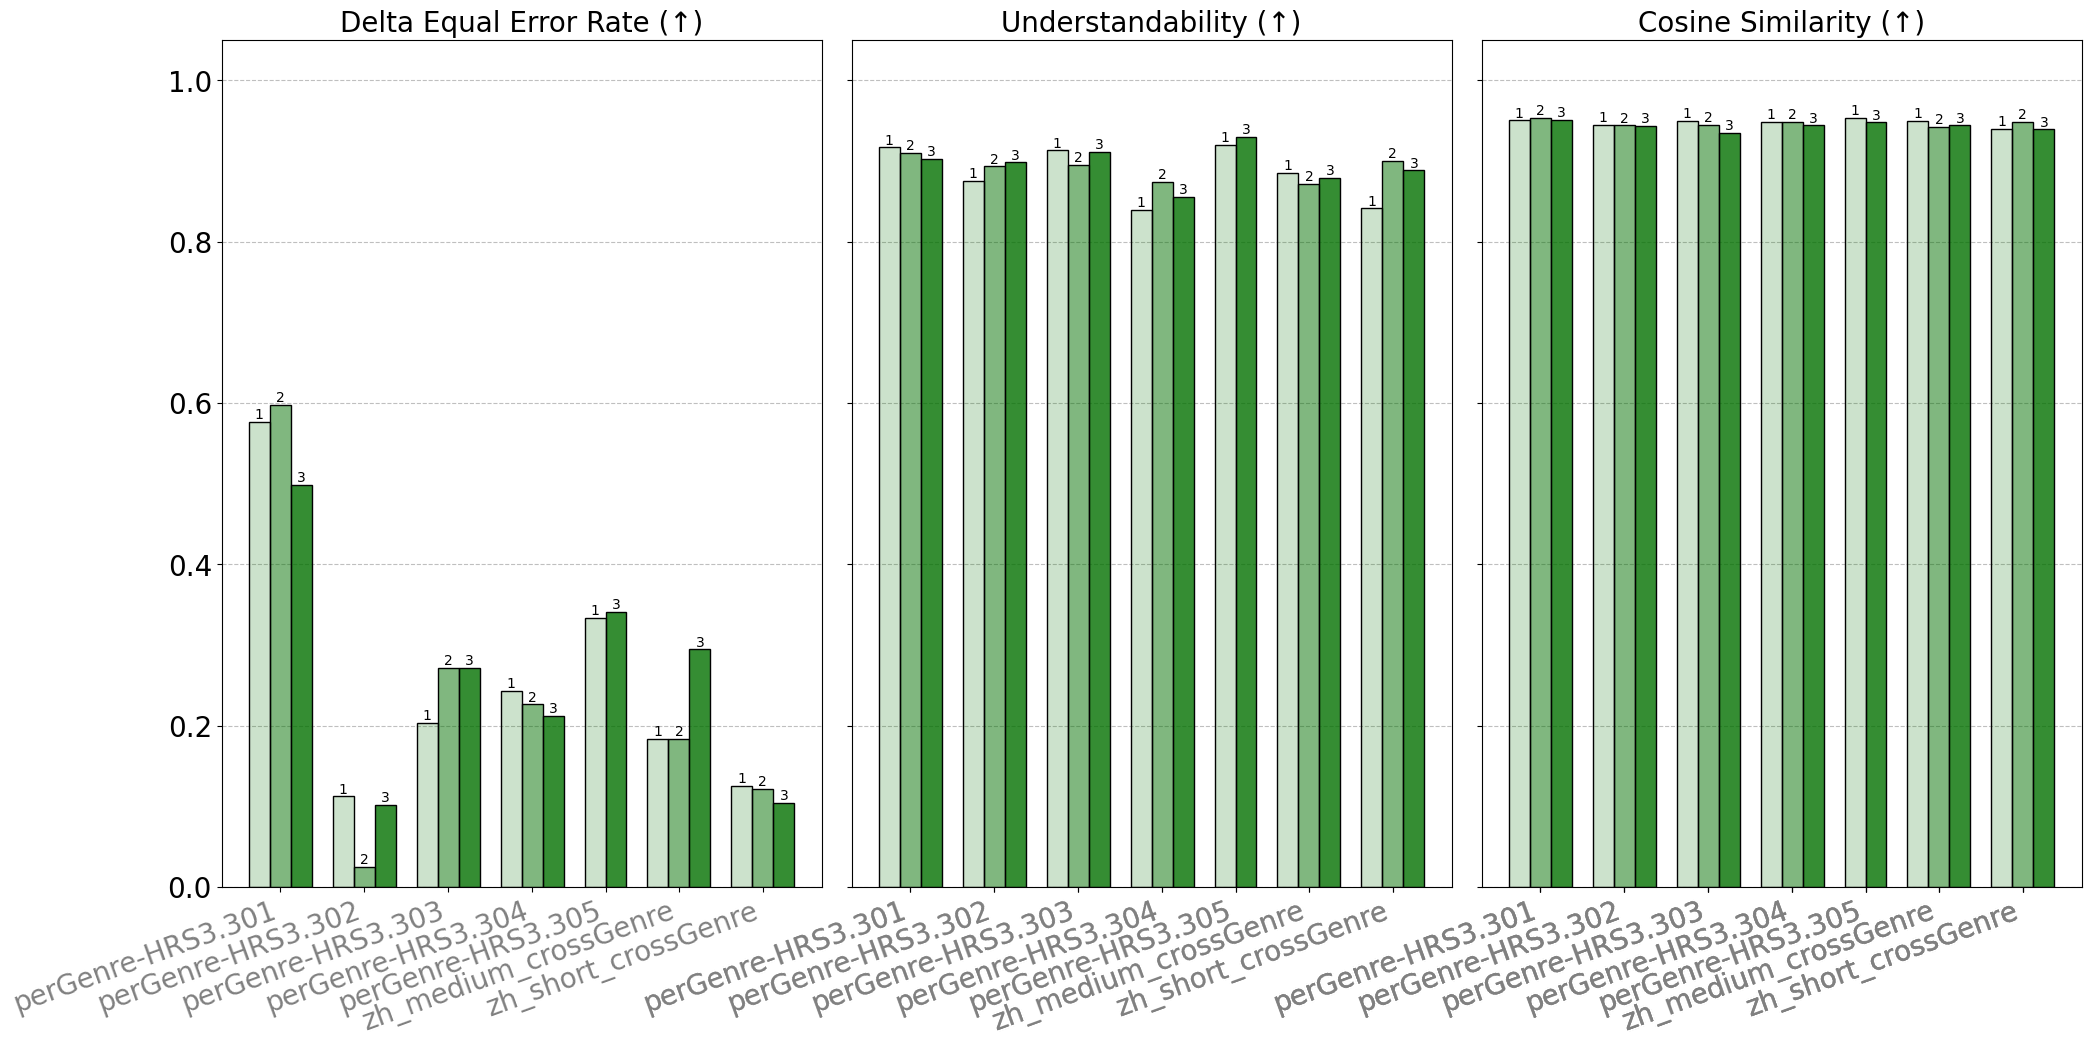

In [16]:
metric_cols = ["delta_equal_error_rate"] + columns_sense  # columns to plot
width = 0.2  # width of each bar within a genre
gap = 0.4    # space between genres

# Filter English HRS2 genres
df_plot = df_merged.copy()
if 'en' in df_plot['language'].unique():
    df_plot = df_plot[~((df_plot['language'] == 'en') & (df_plot['genre'].str.contains('HRS2')))]

# Prettify metric titles
def prettify_title(col):
    return metrics[col]["title"] if col in metrics else col

# Plot each language separately
for lang in df_plot['language'].unique():
    df_lang = df_plot[df_plot['language'] == lang].sort_values(['genre', 'n_styles_to_change'])
    genres = df_lang['genre'].unique()
    
    x_ticks = []
    x_ticklabels = []

    fig, axes = plt.subplots(1, 3, figsize=(24, 11), sharey='row', sharex='col')

    for i, ax in enumerate(axes.flatten()):
        if i >= len(metric_cols):
            ax.axis('off')
            continue

        metric = metric_cols[i]
        cursor = 0

        for genre in genres:
            df_genre = df_lang[df_lang['genre'] == genre].sort_values('n_styles_to_change')
            x = cursor + np.arange(len(df_genre)) * width

            # Map colors and hatches
            repeated_colors = []
            repeated_hatches = []
            for style in df_genre['n_styles_to_change']:
                for m in metrics_path:
                    if (metrics_path[m]['report']
                        and metrics_path[m]['language'] == lang
                        and metrics_path[m]['n_styles_to_change'] == style):
                        repeated_colors.append(metrics_path[m]['color'])
                        repeated_hatches.append('/' if metrics_path[m]['hatch'] else '')

            rect = ax.bar(
                x,
                df_genre[metric],
                width=width,
                color=repeated_colors,
                hatch=repeated_hatches,
                edgecolor='black',
                linewidth=1.0,
                zorder=1
            )

            # Bar labels = n_styles_to_change
            style_labels = df_genre['n_styles_to_change'].astype(str).tolist()
            ax.bar_label(rect, style_labels, padding=0)

            cursor = x[-1] + gap
            x_ticks.append(x.mean())
            x_ticklabels.append(genre)

        # Prettified title per metric
        ax.set_title(prettify_title(metric))
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticklabels, rotation=20, ha='right', color='grey')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', which='major', color='gray', alpha=0.5, linestyle='dashed')
        ax.set_axisbelow(True)
 
    plt.subplots_adjust(wspace=0.05, hspace=0.3)

    path = Path(plots_dir, f"prompt-remix-{lang}-per-genre3.pdf")
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path.as_posix(), bbox_inches="tight")
    plt.show()
